In [1]:
# import pandas --- spreadsheet library
import pandas as pd
import numpy as np
import os

# import matplotlib --- plotting library
import matplotlib.pyplot as plt

from plotting import make_overview, compare, smoothen
from myio import read_in_weather_data

In [2]:
%matplotlib inline

In [3]:

fdir = '../../Data/Calibration Data/Sinarmas/Clean data'

fn = 'Kule-1986.csv'

ydir = 'Yield'

fp = os.path.join(fdir,ydir,fn)

dfo = pd.read_csv(fp)
dfo = dfo.set_index(pd.to_datetime(dfo['Month']))
dfo = dfo.dropna(how='all')

wdir = 'Weather'

fnw = fn.split('-')[0].upper()+'.csv'

fpw = os.path.join(fdir,wdir,fnw)

dfw = read_in_weather_data(fpw)

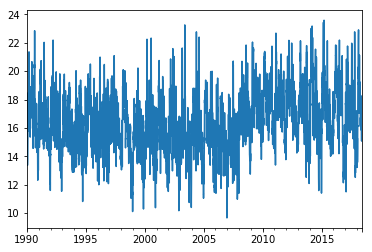

In [4]:
dfw['Solar'].rolling(10).mean().plot()

In [5]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

# 1. Initialize the model
dt = 10

p = PalmField(year_of_planting=1986, month_of_planting=1, dt=dt)
p.planting_density = 143
p.soil.parameters['water_holding_capacity']['value'] = 280

# 2. Couple the solar radiation data:
dfw = dfw.resample('D').pad()
dfw = dfw.rolling(dt, center=True).mean()
dfw = dfw.fillna(method='pad')

p.weather.radiation_series = dfw['Solar']
p.weather.rainfall_series = dfw['Precip']
p.weather.humidity_series = dfw['RelHum']

nyears = 30

duration = nyears*365

df = p.run(duration=duration)

Saving at: plots\KULE-3mo-triMA.png
Saving at: plots\KULE-12mo-triMA.png


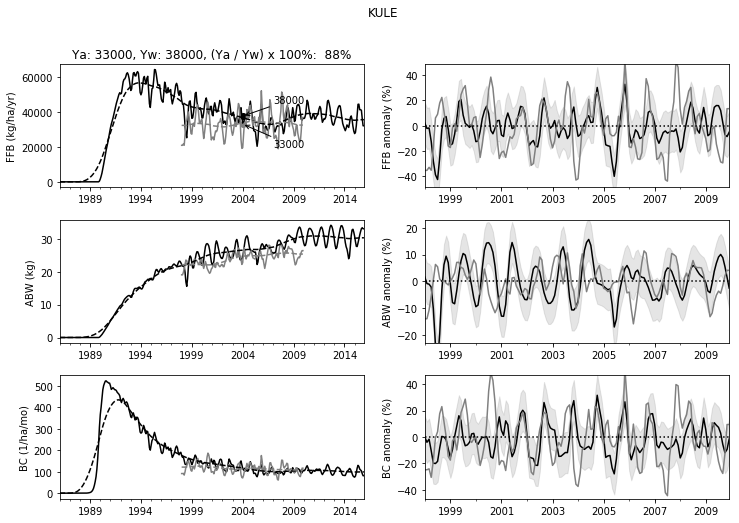

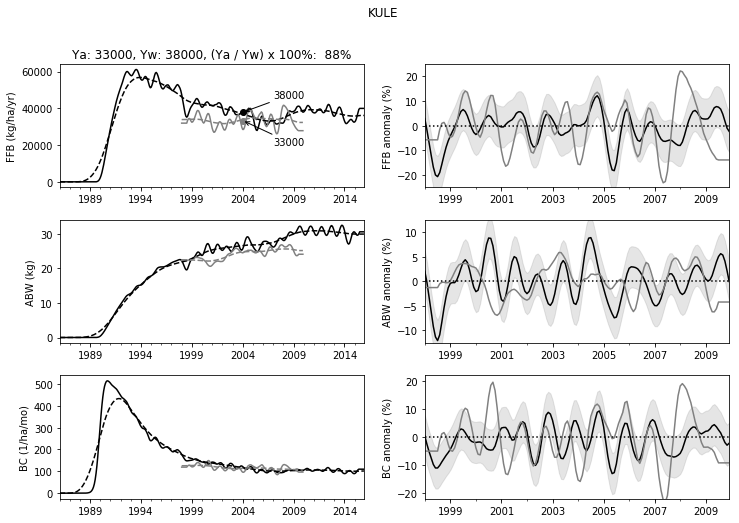

In [6]:
sname = 'KULE'

w = 3

make_overview(df, dfo, sname+'-{:}mo-triMA'.format(w), window=w, title=sname)

w = 12

make_overview(df, dfo, sname+'-{:}mo-triMA'.format(w), window=w, title=sname)